In [4]:
import traceback
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import pandas as pd

# Tangos database configuration
os.environ['TANGOS_DB_CONNECTION'] = '/home/bk639/data/test_dbs/FIRE_test.db'
#os.environ['TANGOS_SIMULATION_FOLDER'] = '/home/bk639/data/CDM_z0'
os.environ['TANGOS_PROPERTY_MODULES'] = 'mytangosproperty'
#add python path /home/bk639/MorphologyMeasurements/Code/tangos
import sys
sys.path.append('/home/bk639/FIRE_analsis_tools/')
import tangos
tangos_sims = tangos.all_simulations()

#load results files
summary_dir = Path("/home/bk639/FIRE_analsis_tools/MCMC_deprojection/results/summary")
with open(summary_dir / "all_individual_results_3Reff_all.pkl", "rb") as f:
    all_individual_results = pickle.load(f)

#create new dataframe, columns are sim_name, halo_id, Q, S, (intrinsics) q, s,(inferred) reff
plot_df = pd.DataFrame(columns=['sim_name', 'halo_id', 'Q', 'S', 'q', 's', 'reff'])
#compare to intrinsic shapes in tangos
for sim_name,hid in all_individual_results:
    try:
        halo = tangos.get_halo(f'{sim_name}/%/{hid}')
        print(halo)
        q,s,q_err,s_err = all_individual_results[sim_name, hid]['max_prob_params']
        # Get the properties
        reff = halo['image_reffs_v'][0]
        rbins_s = halo['rbins_s']
        ba_s = halo['ba_s']
        ca_s = halo['ca_s']
        ba_s_smoothed = halo.calculate('ba_s_smoothed()')
        ca_s_smoothed = halo.calculate('ca_s_smoothed()')
        Q = ba_s_smoothed(2*reff)
        S = ca_s_smoothed(2*reff)

        #make sure these have sane values between 0 and 1
        assert 0 <= Q <= 1, f"simulation {sim_name}, halo {hid}: ba_s out of bounds: {Q}"
        assert 0 <= S <= 1, f"simulation {sim_name}, halo {hid}: ca_s out of bounds: {S}"
        #add data to dataframe
        plot_df = pd.concat([plot_df, pd.DataFrame({'sim_name': [sim_name], 'halo_id': [hid], 'Q': [Q], 'S': [S], 'q': [q], 's': [s], 'reff': [reff]})])
    except Exception as e:
        print(f"Error loading halo {hid} from simulation {sim_name}: {e}")
        continue
    try:
        distance = ((Q - q)**2 + (S - s)**2)**0.5
        if distance > 0.5:
             #figure showing the intrinsic shapes rbins_s vs ba_s, ca_s, and highlighting at 2*reff
            fig, ax = plt.subplots(2, 1, figsize=(12, 12),sharex=True)
            ax[0].scatter(rbins_s, ba_s, label='ba_s',color = 'darkred')
            r_smoothed = np.linspace(min(rbins_s), 2.1*reff, 100)
            ax[0].plot(r_smoothed, ba_s_smoothed(r_smoothed), label='ba_s_smoothed', color='red')
            ax[0].scatter(2*reff, Q, color='red', label='Q',marker='x')
            ax[0].scatter(2*reff, q, color='green', label='q')
            ax[0].set_ylabel('Q')
            ax[1].scatter(rbins_s, ca_s, label='ca_s', color = 'darkblue')
            ax[1].plot(r_smoothed, ca_s_smoothed(r_smoothed), label='ca_s_smoothed', color='blue')
            ax[1].scatter(2*reff, S, color='blue', label='S',marker='x')
            ax[1].scatter(2*reff, s, color = 'green', label='s')
            ax[1].set_xlabel('Radius (kpc)')
            ax[1].set_ylabel('S')
             #set xlim to 0, 2*reff
            ax[0].set_xlim(0, 2.1*reff)
            ax[1].set_xlim(0, 2.1*reff)
            #set ylim to 0, 1
            ax[0].set_ylim(0, 1)
            ax[1].set_ylim(0, 1)
            #set title to sim_name, halo_id
            ax[0].set_title(f"Simulation: {sim_name}, Halo ID: {hid}")
            #close the figure
            plt.close(fig)
         
            
    except Exception as e:
        print(f"Error plotting halo {hid} from simulation {sim_name}: {e}")
        print(traceback.format_exc())
        break





<Halo 'm11d_res7100/600/halo_1' | NDM=7522506 Nstar=743938 Ngas=1406230>


/tmp/ipykernel_3272958/1683846895.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  plot_df = pd.concat([plot_df, pd.DataFrame({'sim_name': [sim_name], 'halo_id': [hid], 'Q': [Q], 'S': [S], 'q': [q], 's': [s], 'reff': [reff]})])


<Halo 'm11d_res7100/600/halo_2' | NDM=1179169 Nstar=59566 Ngas=216525>
<Halo 'm11d_res7100/600/halo_4' | NDM=114944 Nstar=8394 Ngas=1874>
<Halo 'm11b_res2100/600/halo_1' | NDM=4236396 Nstar=28274 Ngas=556233>
<Halo 'm11e_res7100/600/halo_1' | NDM=4017612 Nstar=259390 Ngas=632872>
<Halo 'm11e_res7100/600/halo_2' | NDM=2055267 Nstar=17717 Ngas=383870>
<Halo 'm11h_res7100/600/halo_1' | NDM=4880320 Nstar=684894 Ngas=732743>
<Halo 'm11i_res7100/600/halo_1' | NDM=1868196 Nstar=170487 Ngas=276734>
<Halo 'm11q_res880/600/halo_1' | NDM=34974374 Nstar=540178 Ngas=2540611>
<Halo 'm11q_res880/600/halo_2' | NDM=7811615 Nstar=64010 Ngas=247582>
<Halo 'm11q_res880/600/halo_3' | NDM=5880809 Nstar=54965 Ngas=73828>
<Halo 'm11q_res880/600/halo_4' | NDM=4784393 Nstar=23206 Ngas=45588>
<Halo 'm11q_res880/600/halo_5' | NDM=3644291 Nstar=14790 Ngas=315739>
<Halo 'm11q_res880/600/halo_6' | NDM=3419662 Nstar=6106 Ngas=252160>


In [ ]:
((plot_df['Q'] - plot_df['q'])**2  + (plot_df['S'] - plot_df['s'])**2)**0.5

In [ ]:
#print rows where the distance between intrinsic and inferred shapes is greater than 0.3
distance = ((plot_df['Q'] - plot_df['q'])**2 + (plot_df['S'] - plot_df['s'])**2)**0.5
mask = distance > 0.3
plot_df[mask]

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import colorsys

class ShapePlotter:
    def __init__(self, df):
        """
        Initialize the ShapePlotter with a DataFrame.

        Parameters:
        -----------
        df : pandas.DataFrame
            DataFrame containing the data with columns 'Q', 'S', 'q', 's', 'sim_name', 'halo_id'
        """
        self.df = df
        self.masks = {}
        self.mask_colors = {}
        self.mask_labels = {}

        # Styling parameters - taken from GeneralPlotter
        self.legend_fontsize = 20
        self.axis_fontsize = 33
        self.tick_fontsize = 20
        self.point_size = 120

        # Add a default mask for all data
        self.add_mask("all", np.ones(len(df), dtype=bool), color="blue", label="All Data")

    def lighten_color(self, color, amount=0.5):
        """
        Lightens the given color by multiplying (1-luminosity) by the given amount.
        Based on the function from the provided GeneralPlotter class.
        """
        try:
            c = plt.matplotlib.colors.cnames[color]
        except:
            c = color
        c = colorsys.rgb_to_hls(*plt.matplotlib.colors.to_rgb(c))
        return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

    def add_mask(self, name, mask, color=None, label=None):
        """
        Add a mask to the plotter.

        Parameters:
        -----------
        name : str
            Name of the mask
        mask : array-like
            Boolean array of the same length as the dataframe
        color : str, optional
            Color to use for this mask. If None, a default color is chosen.
        label : str, optional
            Label to use for this mask in the legend. If None, the mask name is used.
        """
        self.masks[name] = mask

        if color is None:
            default_colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
            color = default_colors[len(self.masks) % len(default_colors)]

        self.mask_colors[name] = color

        if label is None:
            label = name

        self.mask_labels[name] = label

    def plot_QS_qs(self, ax=None, save_path=None, title=None, show_lines=True):
        """
        Plot Q vs S and q vs s on the same plot, with lines linking points (Q,S) and (q,s)
        for the same sim/halo pair.

        Parameters:
        -----------
        ax : matplotlib.axes.Axes, optional
            The axes to plot on. If None, a new figure and axes are created.
        save_path : str, optional
            Path to save the figure. If None, the figure is displayed but not saved.
        title : str, optional
            Title for the plot. If None, a default title is used.
        show_lines : bool, optional
            Whether to show lines linking (Q,S) and (q,s) points. Default is True.

        Returns:
        --------
        fig : matplotlib.figure.Figure
            The figure object
        ax : matplotlib.axes.Axes
            The axes object
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 10))
        else:
            fig = ax.figure

        # Plot for each mask
        for mask_name, mask in self.masks.items():
            color = self.mask_colors[mask_name]
            label = self.mask_labels[mask_name]
            if label == "All Data":
                label = ""

            # Get the masked dataframe
            mask_df = self.df[mask]

            if len(mask_df) == 0:
                continue

            # Plot (Q,S) points
            ax.scatter(mask_df['Q'], mask_df['S'], c=color, marker='o', s=self.point_size,
                      alpha=1, zorder=10, edgecolors='white', label=f'{label} Intrinsic')

            # Plot (q,s) points - using lightened color for clarity
            ax.scatter(mask_df['q'], mask_df['s'], c=[self.lighten_color(color, 1.5)],
                      marker='*', s=self.point_size*3.5, alpha=1, zorder=10,
                      edgecolors='white', label=f'{label} Inferred')

            # Draw lines linking (Q,S) and (q,s) for the same sim/halo pair
            if show_lines:
                for _, row in mask_df.iterrows():
                    ax.plot([row['Q'], row['q']], [row['S'], row['s']],
                            zorder=0, lw=0.5, c='k', alpha=0.7)

        # Set axis labels and title
        ax.set_ylabel(r'$S$ & $s$', fontsize=self.axis_fontsize)
        ax.set_xlabel(r'$Q$ & $q$', fontsize=self.axis_fontsize)

        # Set tick parameters
        ax.tick_params(axis='both', which='major', labelsize=self.tick_fontsize)

        # Add legend
        ax.legend(fontsize=self.legend_fontsize)

        # Set axis limits
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        # Plot identity line
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.7)

        # Add shaded region where x > 0.65 and y < 0.4 (from the original plotter)
        ax.fill_between([0.65, 1], 0, 0.4, color='0.75', alpha=0.3)

        #make sure plot is square
        ax.set_aspect('equal', adjustable='box')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        return fig, ax

    def plot_Qq(self, ax=None, save_path=None, title=None):
        """
        Plot Q vs q.

        Parameters:
        -----------
        ax : matplotlib.axes.Axes, optional
            The axes to plot on. If None, a new figure and axes are created.
        save_path : str, optional
            Path to save the figure. If None, the figure is displayed but not saved.
        title : str, optional
            Title for the plot. If None, a default title is used.

        Returns:
        --------
        fig : matplotlib.figure.Figure
            The figure object
        ax : matplotlib.axes.Axes
            The axes object
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 8))
        else:
            fig = ax.figure

        # Plot for each mask
        for mask_name, mask in self.masks.items():
            color = self.mask_colors[mask_name]
            label = self.mask_labels[mask_name]

            # Get the masked dataframe
            mask_df = self.df[mask]

            if len(mask_df) == 0:
                continue

            # Plot Q vs q
            ax.scatter(mask_df['q'], mask_df['Q'], c=color, marker='o', s=self.point_size,
                      alpha=1, zorder=10, edgecolors='white', label=label)

        # Plot identity line
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.7)

        # Set axis labels and title
        ax.set_xlabel(r'$q$ (Inferred)', fontsize=self.axis_fontsize)
        ax.set_ylabel(r'$Q$ (Intrinsic)', fontsize=self.axis_fontsize)

        # Set tick parameters
        ax.tick_params(axis='both', which='major', labelsize=self.tick_fontsize)

        # Add legend
        ax.legend(fontsize=self.legend_fontsize)

        # Set axis limits
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

                #make sure plot is square
        ax.set_aspect('equal', adjustable='box')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        return fig, ax

    def plot_Ss(self, ax=None, save_path=None, title=None):
        """
        Plot S vs s.

        Parameters:
        -----------
        ax : matplotlib.axes.Axes, optional
            The axes to plot on. If None, a new figure and axes are created.
        save_path : str, optional
            Path to save the figure. If None, the figure is displayed but not saved.
        title : str, optional
            Title for the plot. If None, a default title is used.

        Returns:
        --------
        fig : matplotlib.figure.Figure
            The figure object
        ax : matplotlib.axes.Axes
            The axes object
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 8))
        else:
            fig = ax.figure

        # Plot for each mask
        for mask_name, mask in self.masks.items():
            color = self.mask_colors[mask_name]
            label = self.mask_labels[mask_name]

            # Get the masked dataframe
            mask_df = self.df[mask]

            if len(mask_df) == 0:
                continue

            # Plot S vs s
            ax.scatter(mask_df['s'], mask_df['S'], c=color, marker='o', s=self.point_size,
                      alpha=1, zorder=10, edgecolors='white', label=label)

        # Plot identity line
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.7)

        # Set axis labels and title
        ax.set_xlabel(r'$s$ (Inferred)', fontsize=self.axis_fontsize)
        ax.set_ylabel(r'$S$ (Intrinsic)', fontsize=self.axis_fontsize)


        # Set tick parameters
        ax.tick_params(axis='both', which='major', labelsize=self.tick_fontsize)

        # Add legend
        ax.legend(fontsize=self.legend_fontsize)

        # Set axis limits
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        #make sure plot is square
        ax.set_aspect('equal', adjustable='box')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        return fig, ax

    def plot_Qq_Ss(self, save_path=None, title=None):
        """
        Create two plots: Q vs q and S vs s, side by side.

        Parameters:
        -----------
        save_path : str, optional
            Path to save the figure. If None, the figure is displayed but not saved.
        title : str, optional
            Title for the plot. If None, a default title is used.

        Returns:
        --------
        fig : matplotlib.figure.Figure
            The figure object
        axes : tuple
            Tuple of two axes objects (ax1, ax2)
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        self.plot_Qq(ax=ax1)
        self.plot_Ss(ax=ax2)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        return fig, (ax1, ax2)

    def set_style(self, legend_fontsize=None, axis_fontsize=None,
                 tick_fontsize=None, point_size=None):
        """
        Set styling parameters for the plots.

        Parameters:
        -----------
        legend_fontsize : int, optional
            Font size for legend
        axis_fontsize : int, optional
            Font size for axis labels
        tick_fontsize : int, optional
            Font size for tick labels
        point_size : int, optional
            Size of scatter points
        """
        if legend_fontsize is not None:
            self.legend_fontsize = legend_fontsize
        if axis_fontsize is not None:
            self.axis_fontsize = axis_fontsize
        if tick_fontsize is not None:
            self.tick_fontsize = tick_fontsize
        if point_size is not None:
            self.point_size = point_size

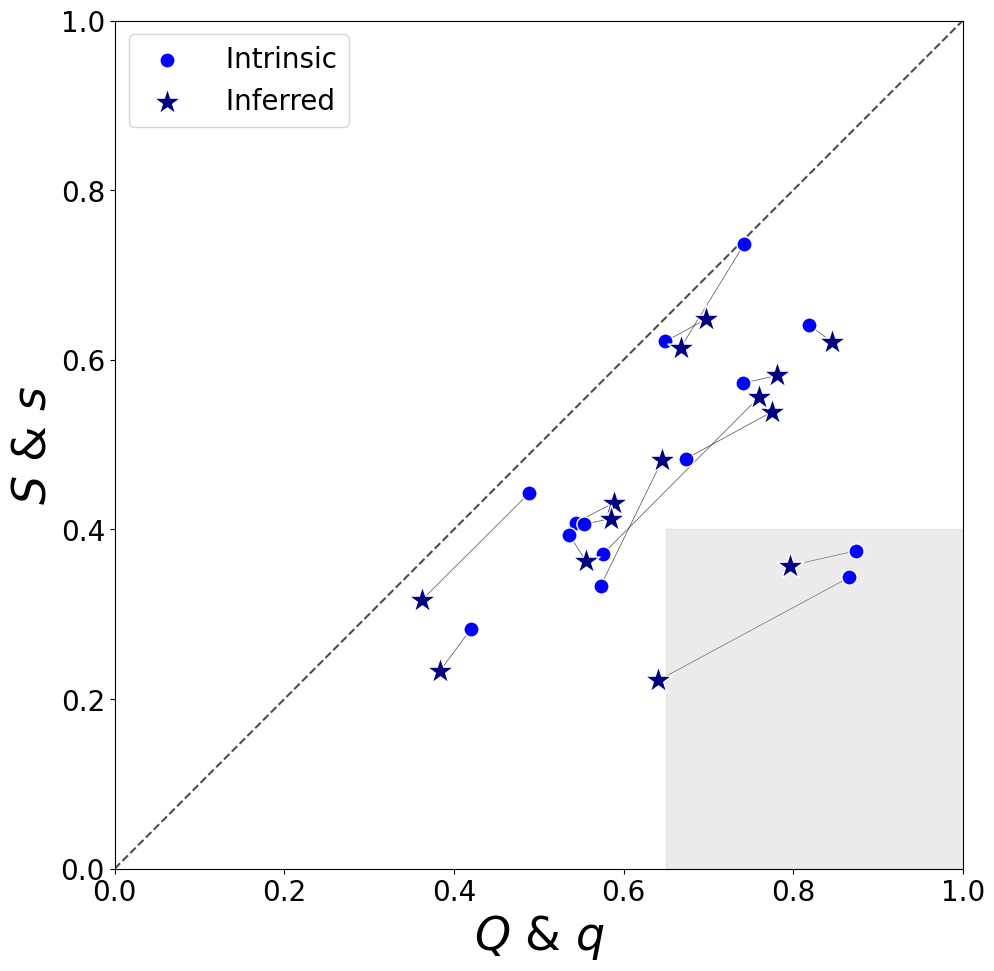

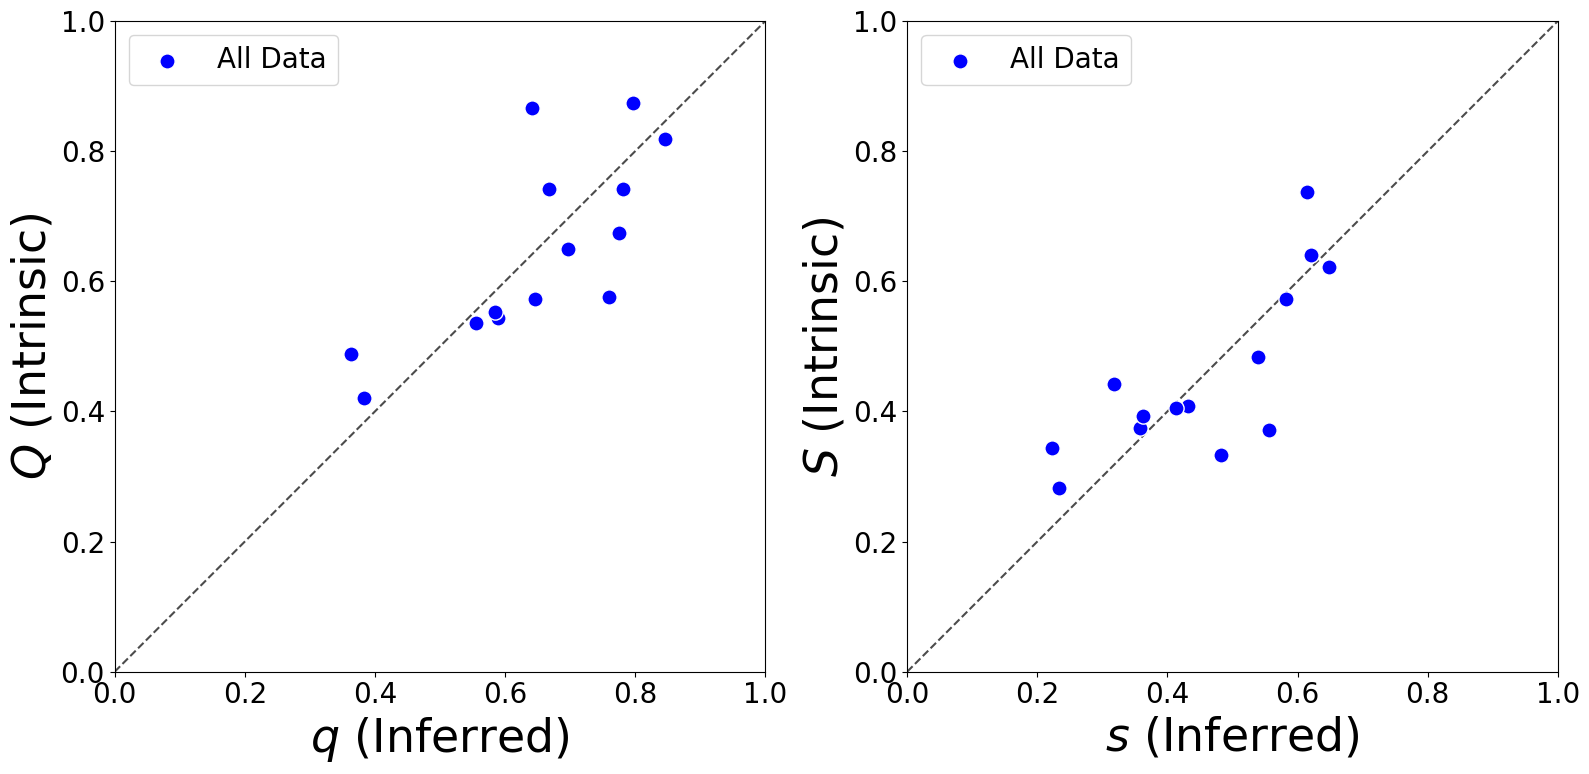

In [6]:
# Create a ShapePlotter instance
plotter = ShapePlotter(plot_df)

folder = '/home/bk639/OverLeaf/InferencePaper/'
# Example 1: Basic plots without masks
# ===================================

# Plot Q vs S and q vs s on the same plot, with lines linking the points
fig1, ax1 = plotter.plot_QS_qs(save_path=folder + "QS_qs_plot.png", title="Q,S vs q,s Plot")

# Plot Q vs q and S vs s side by side
fig2, (ax2, ax3) = plotter.plot_Qq_Ss(save_path=folder + "Qq_Ss_plots.png", title="Comparison Plots")

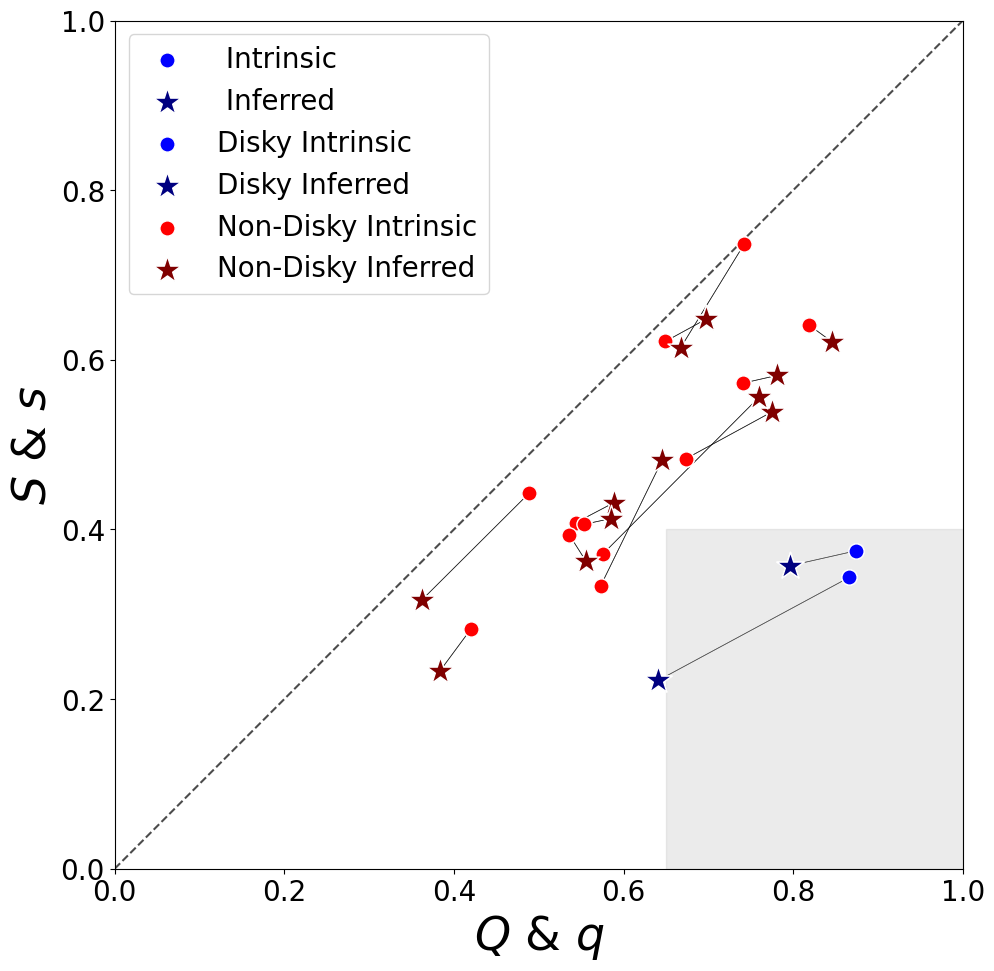

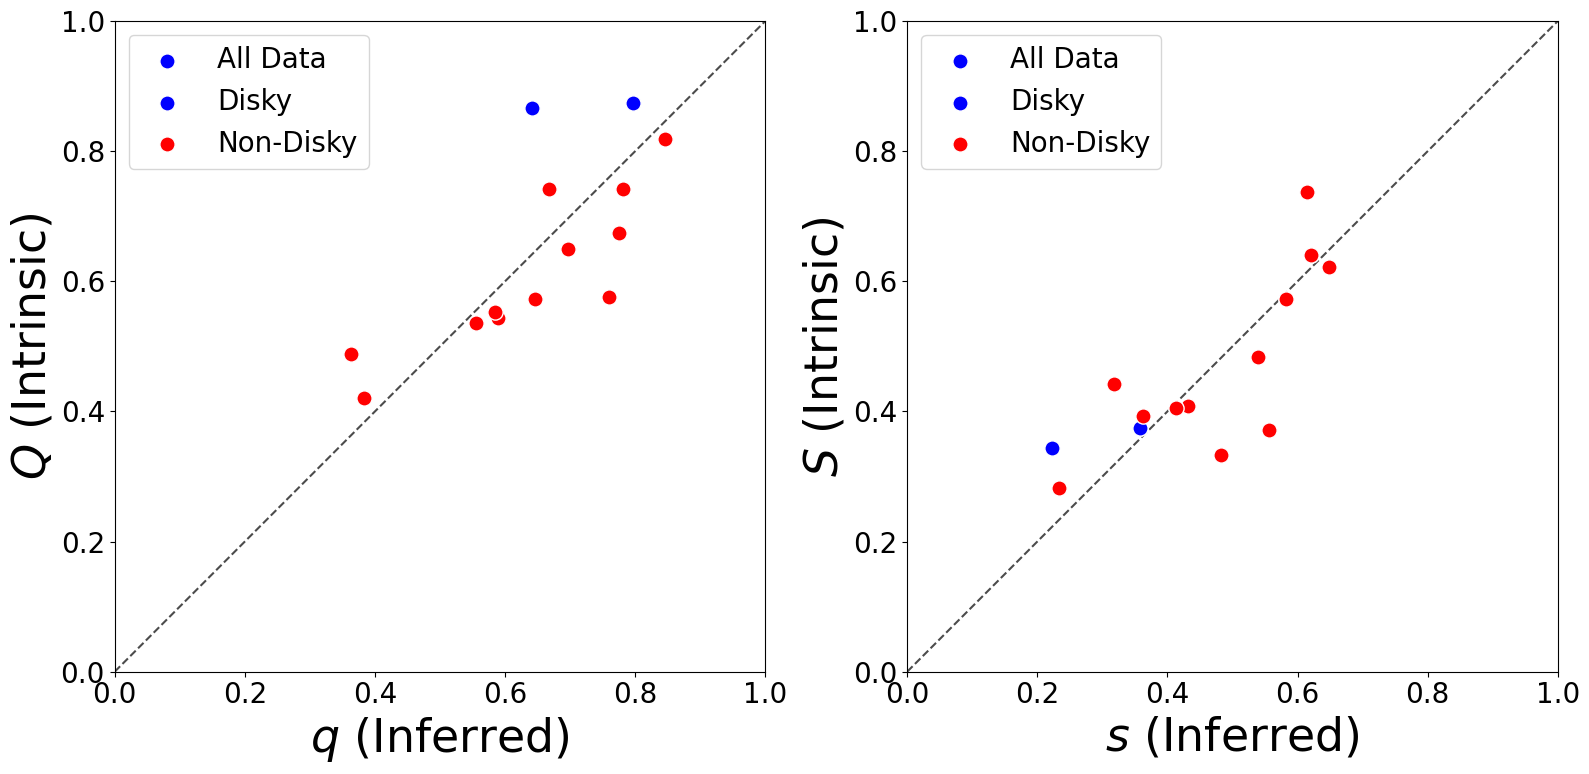

In [7]:
#create plots for masks of disky and non-disky
# Create masks for disky and non-disky
disky_mask = (plot_df['Q'] > 0.65) & (plot_df['S'] < 0.4)
non_disky_mask = ~disky_mask
# Add masks to the plotter
plotter.add_mask("Disky", disky_mask, color="blue", label="Disky")
plotter.add_mask("Non-Disky", non_disky_mask, color="red", label="Non-Disky")
# Plot Q vs S and q vs s on the same plot, with lines linking the points
fig3, ax4 = plotter.plot_QS_qs(save_path=folder + "QS_qs_plot_disky_nondisky.png", title="Q,S vs q,s Plot with Disky and Non-Disky Masks")
# Plot Q vs q and S vs s side by side
fig4, (ax5, ax6) = plotter.plot_Qq_Ss(save_path=folder + "Qq_Ss_plots_disky_nondisky.png", title="Comparison Plots with Disky and Non-Disky Masks")



Loaded categories: ['All Galaxies' 'Disky Galaxies' 'Non-Disky Galaxies']
Saved: results/plots/all_galaxies_2.0Reff_clean.png


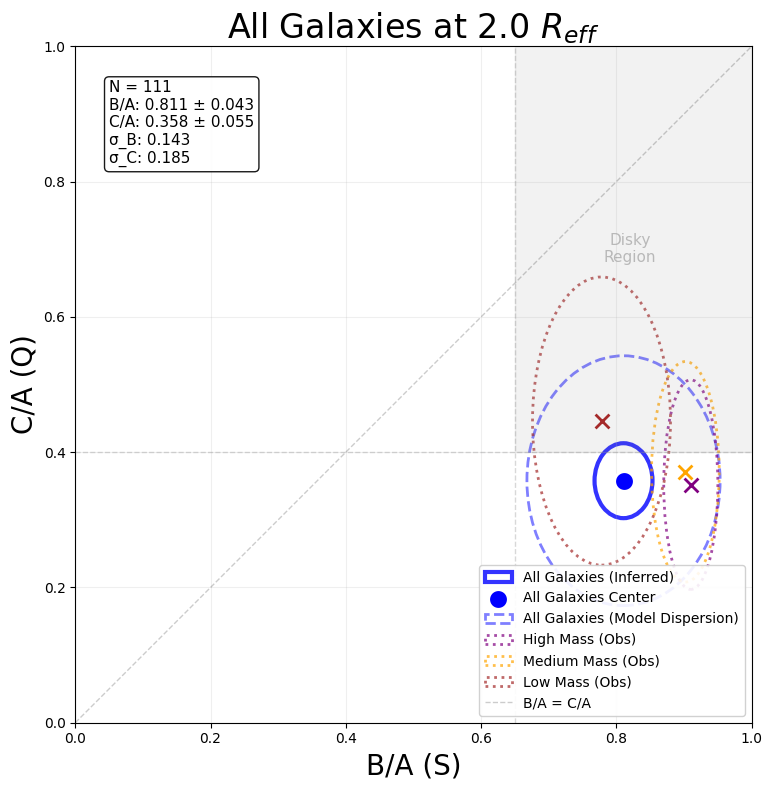

Saved: results/plots/disky_galaxies_2.0Reff_clean.png


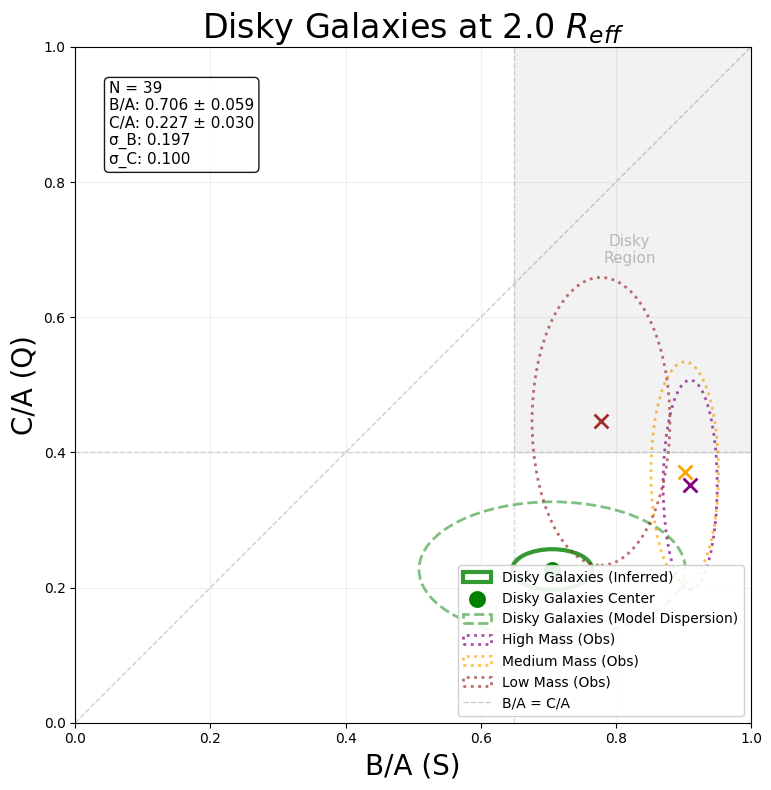

Saved: results/plots/non-disky_galaxies_2.0Reff_clean.png


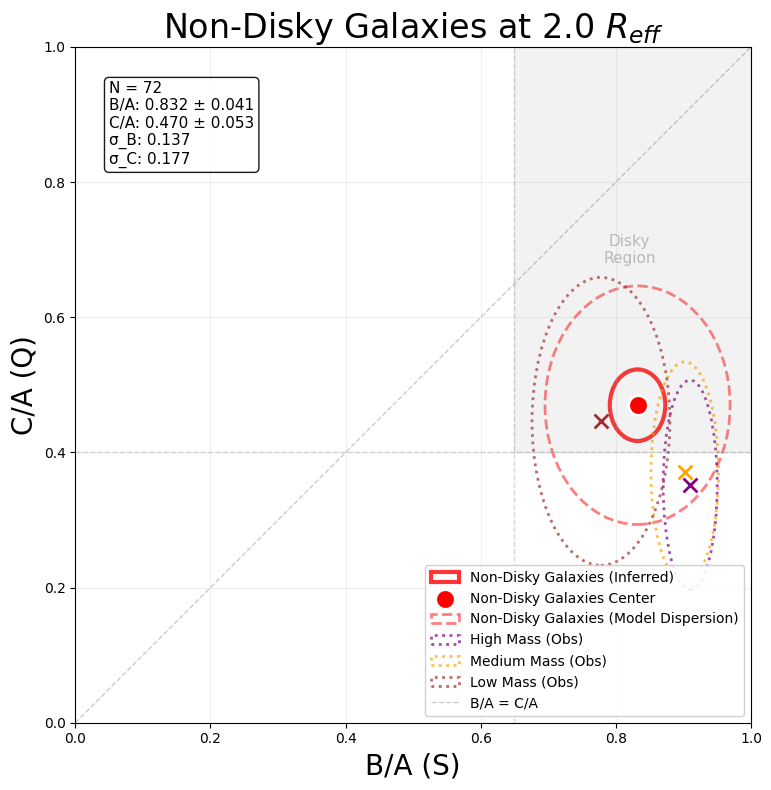

Saved: results/plots/combined_clean_2.0Reff.png


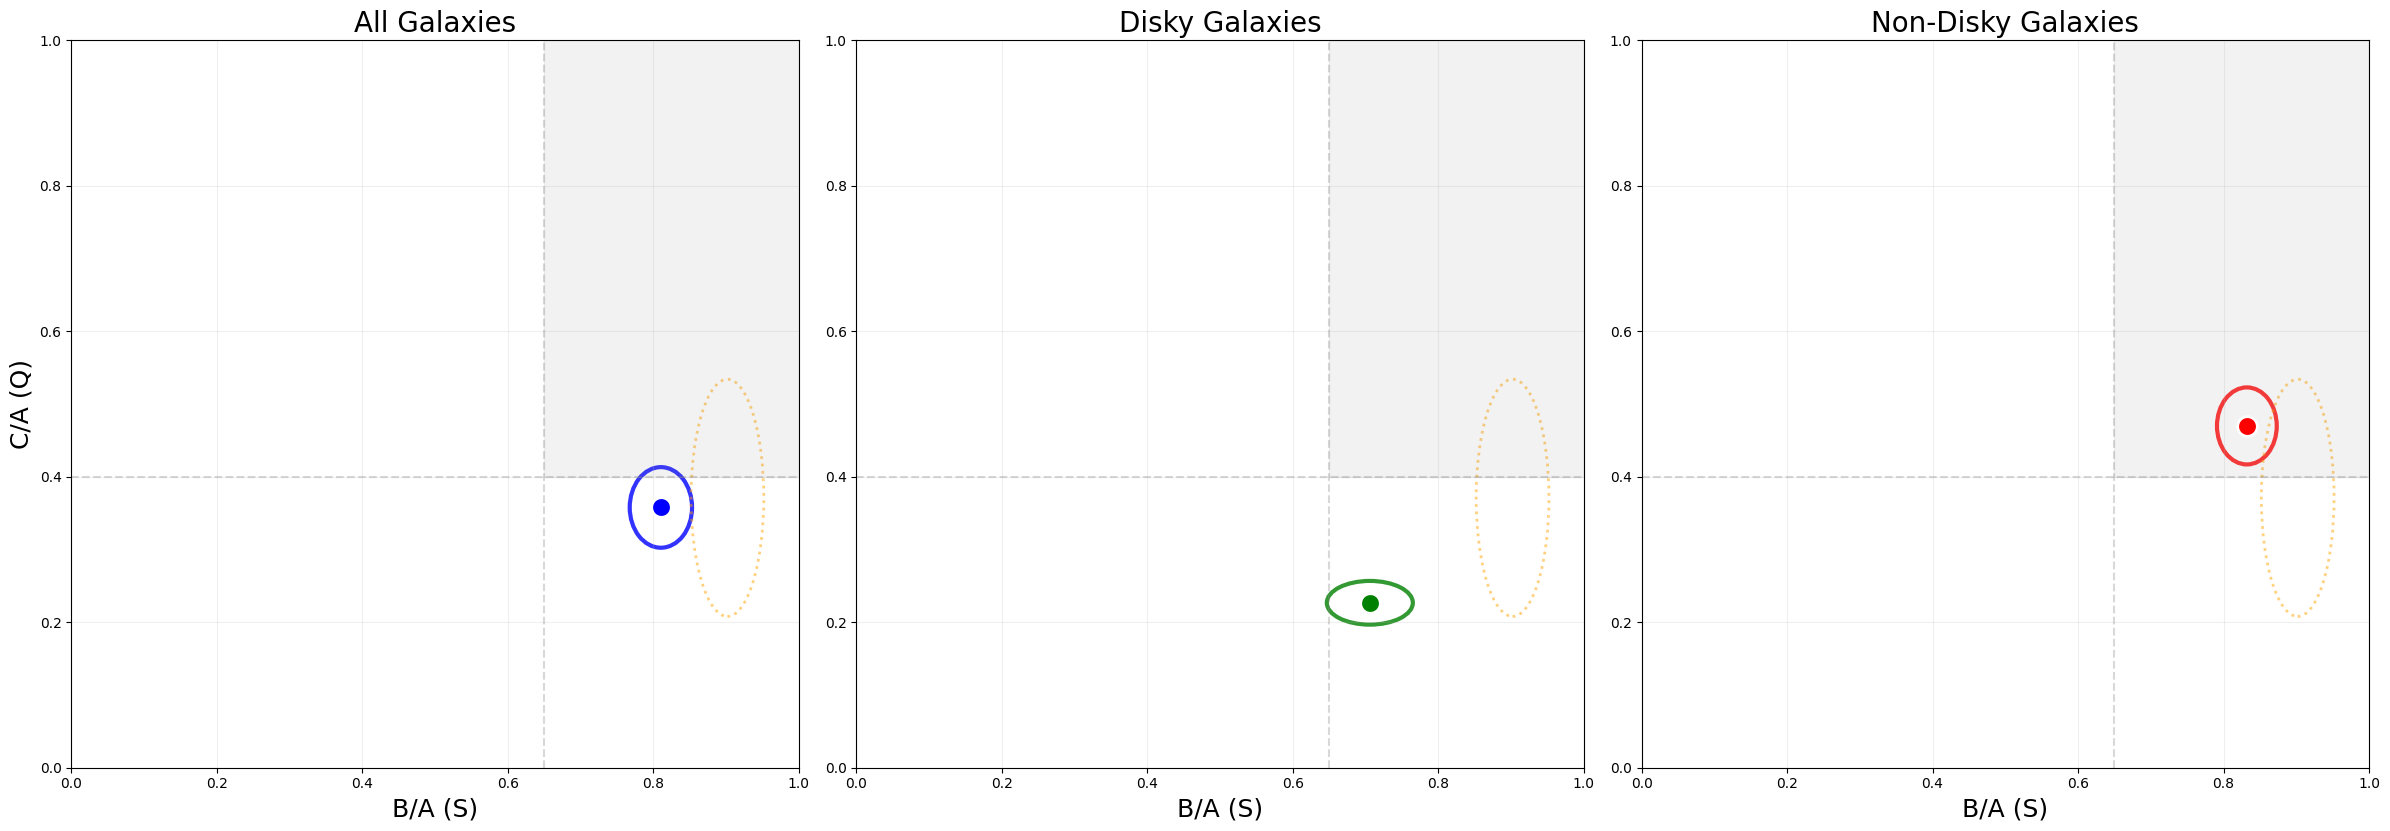


Summary Statistics:

All Galaxies (N=111):
  B/A: 0.811 (mean), 0.819 (max prob)
  C/A: 0.358 (mean), 0.326 (max prob)
  σ_B: 0.143
  σ_C: 0.185

Disky Galaxies (N=39):
  B/A: 0.706 (mean), 0.706 (max prob)
  C/A: 0.227 (mean), 0.196 (max prob)
  σ_B: 0.197
  σ_C: 0.100

Non-Disky Galaxies (N=72):
  B/A: 0.832 (mean), 0.824 (max prob)
  C/A: 0.470 (mean), 0.448 (max prob)
  σ_B: 0.137
  σ_C: 0.177


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse

# KF observational data
KF_DATA = {
    'KF High Mass': {
        '1R_eff': {'center': (0.863, 0.297), 'std': (0.075, 0.103)},
        '2R_eff': {'center': (0.91, 0.352), 'std': (0.04, 0.155)}
    },
    'KF Medium Mass': {
        '1R_eff': {'center': (0.857, 0.323), 'std': (0.05, 0.118)},
        '2R_eff': {'center': (0.902, 0.371), 'std': (0.05, 0.163)}
    },
    'KF Low Mass': {
        '1R_eff': {'center': (0.753, 0.459), 'std': (0.087, 0.194)},
        '2R_eff': {'center': (0.778, 0.446), 'std': (0.102, 0.213)}
    }
}


def load_full_summary_csv(csv_path):
    """
    Load the full individual or combined summary CSV that has standard deviations.

    Parameters:
    -----------
    csv_path : str
        Path to a summary CSV with B/A_std and C/A_std columns

    Returns:
    --------
    dict
        Dictionary with mean and std values for B/A and C/A
    """
    df = pd.read_csv(csv_path)

    # Get the first row (for combined) or aggregate (for individual)
    if len(df) == 1:
        row = df.iloc[0]
    else:
        # If multiple rows, calculate aggregate statistics
        row = {
            'B/A_mean': df['B/A Mean'].mean() if 'B/A Mean' in df else df['B/A_mean'].mean(),
            'B/A_std': df['B/A Std'].mean() if 'B/A Std' in df else df['B/A_std'].mean(),
            'C/A_mean': df['C/A Mean'].mean() if 'C/A Mean' in df else df['C/A_mean'].mean(),
            'C/A_std': df['C/A Std'].mean() if 'C/A Std' in df else df['C/A_std'].mean()
        }
        return row

    result = {}
    # Check for different column naming conventions
    if 'B/A_mean' in df.columns:
        result['B/A_mean'] = row['B/A_mean']
        result['B/A_std'] = row['B/A_std']
        result['C/A_mean'] = row['C/A_mean']
        result['C/A_std'] = row['C/A_std']
    else:
        result['B/A_mean'] = row['B/A Mean'] if 'B/A Mean' in row else row['B/A_mean']
        result['B/A_std'] = row['B/A Std'] if 'B/A Std' in row else row['B/A_std']
        result['C/A_mean'] = row['C/A Mean'] if 'C/A Mean' in row else row['C/A_mean']
        result['C/A_std'] = row['C/A Std'] if 'C/A Std' in row else row['C/A_std']

    # Also get max prob if available
    if 'B/A_max_prob' in df.columns or 'Inferred B/A' in df.columns:
        result['B/A_max_prob'] = row['B/A_max_prob'] if 'B/A_max_prob' in row else row.get('Inferred B/A', result['B/A_mean'])
        result['C/A_max_prob'] = row['C/A_max_prob'] if 'C/A_max_prob' in row else row.get('Inferred C/A', result['C/A_mean'])

    return result


def plot_galaxy_shapes_proper(category_csv='results/summary/category_comparison.csv',
                              full_summary_csvs=None,
                              radius_reff=2.0,
                              show_kf_all=True,
                              save_plots=True,
                              output_dir='results/plots'):
    """
    Plot galaxy shape distributions with proper standard deviations and KF observational data.

    Parameters:
    -----------
    category_csv : str
        Path to category_comparison.csv with basic statistics
    full_summary_csvs : dict, optional
        Dictionary mapping category names to full summary CSV paths with std deviations
        e.g., {'All Galaxies': 'results/summary/combined_summary_all.csv', ...}
    radius_reff : float
        Radius in R_eff (1.0 or 2.0)
    show_kf_all : bool
        If True, show all KF mass bins; if False, show only medium mass
    save_plots : bool
        Whether to save the plots
    output_dir : str
        Directory to save plots
    """

    import os
    os.makedirs(output_dir, exist_ok=True)

    # Load category comparison data
    category_df = pd.read_csv(category_csv)
    print(f"Loaded categories: {category_df['Category'].values}")

    radius_key = f'{int(radius_reff)}R_eff'

    # Define colors for each category
    category_colors = {
        'All Galaxies': 'blue',
        'Disky Galaxies': 'green',
        'Non-Disky Galaxies': 'red',
        'Non_Disky Galaxies': 'red'
    }

    # KF colors
    kf_colors = {
        'KF High Mass': 'purple',
        'KF Medium Mass': 'orange',
        'KF Low Mass': 'brown'
    }

    # Create individual plots for each category
    for idx, row in category_df.iterrows():
        category = row['Category']

        fig, ax = plt.subplots(figsize=(8, 8))

        # Get color for this category
        color = category_colors.get(category, 'blue')

        # Try to load full statistics if available
        ba_std = None
        ca_std = None

        if full_summary_csvs and category in full_summary_csvs:
            try:
                full_stats = load_full_summary_csv(full_summary_csvs[category])
                ba_mean = full_stats['B/A_mean']
                ca_mean = full_stats['C/A_mean']
                ba_std = full_stats['B/A_std']
                ca_std = full_stats['C/A_std']
                print(f"Loaded full statistics for {category}")
            except:
                print(f"Could not load full statistics for {category}, using category_comparison values")
                ba_mean = row['B/A_mean']
                ca_mean = row['C/A_mean']
        else:
            ba_mean = row['B/A_mean']
            ca_mean = row['C/A_mean']

        # If we don't have proper std, estimate from model dispersion parameters
        # Note: This is an approximation - ideally load from full summary
        if ba_std is None:
            # Model dispersion parameters are not the same as distribution std
            # This is a rough approximation - better to use actual MCMC sample std
            ba_std = row['sigmaB_mean'] * 0.3  # Scaling factor - adjust based on your data
            ca_std = row['sigmaC_mean'] * 0.3
            print(f"Warning: Using approximated std from model parameters for {category}")

        # Plot inferred ellipse (1-sigma)
        ellipse_inferred = Ellipse((ba_mean, ca_mean),
                                  width=2*ba_std, height=2*ca_std,
                                  edgecolor=color, facecolor='none',
                                  lw=3, label=f'{category} (Inferred)',
                                  alpha=0.8)
        ax.add_patch(ellipse_inferred)

        # Add center point
        ax.scatter(ba_mean, ca_mean, c=color, s=200, marker='o',
                  zorder=5, edgecolors='white', linewidth=2,
                  label=f'{category} Center')

        # Plot model dispersion ellipse (sigmaB, sigmaC) if meaningful
        sigmaB = row['sigmaB_mean']
        sigmaC = row['sigmaC_mean']

        # Only plot if dispersions are meaningful (not too small or extreme)
        if (sigmaB > 0.05 or sigmaC > 0.05) and (sigmaB/sigmaC < 10 and sigmaC/sigmaB < 10):
            ellipse_dispersion = Ellipse((ba_mean, ca_mean),
                                        width=2*sigmaB, height=2*sigmaC,
                                        edgecolor=color, facecolor='none',
                                        lw=2, linestyle='--',
                                        label=f'{category} (Model Dispersion)',
                                        alpha=0.5)
            ax.add_patch(ellipse_dispersion)

        # Add KF observational data
        if show_kf_all:
            # Show all three mass bins
            for mass_bin, kf_color in kf_colors.items():
                if radius_key in KF_DATA[mass_bin]:
                    data = KF_DATA[mass_bin][radius_key]
                    mass_label = mass_bin.replace('KF ', '')

                    ellipse_kf = Ellipse(data['center'],
                                        width=2*data['std'][0],
                                        height=2*data['std'][1],
                                        edgecolor=kf_color, facecolor='none',
                                        lw=2, linestyle=':',
                                        label=f'{mass_label} (Obs)',
                                        alpha=0.7)
                    ax.add_patch(ellipse_kf)

                    # Add center point
                    ax.scatter(data['center'][0], data['center'][1],
                             c=kf_color, s=100, marker='x',
                             zorder=5, linewidth=2)
        else:
            # Show only medium mass
            mass_bin = 'KF Medium Mass'
            if radius_key in KF_DATA[mass_bin]:
                data = KF_DATA[mass_bin][radius_key]
                ellipse_kf = Ellipse(data['center'],
                                    width=2*data['std'][0],
                                    height=2*data['std'][1],
                                    edgecolor=kf_colors[mass_bin], facecolor='none',
                                    lw=2, linestyle=':',
                                    label='KF Medium Mass (Obs)',
                                    alpha=0.7)
                ax.add_patch(ellipse_kf)

        # Add disky/non-disky boundary region
        ax.axvline(x=0.65, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        ax.axhline(y=0.4, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        ax.fill([0.65, 1, 1, 0.65], [0.4, 0.4, 1, 1],
                color='gray', alpha=0.1)
        ax.text(0.82, 0.7, 'Disky\nRegion', fontsize=11,
                ha='center', va='center', color='gray', alpha=0.5)

        # Add diagonal line
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.2, linewidth=1, label='B/A = C/A')

        # Set limits and labels
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('B/A (S)', fontsize=20)
        ax.set_ylabel('C/A (Q)', fontsize=20)
        ax.set_title(f'{category} at {radius_reff:.1f} $R_{{eff}}$', fontsize=24)

        # Add statistics text box
        stats_text = f'N = {int(row["N_Halos"])}\n'
        stats_text += f'B/A: {ba_mean:.3f} ± {ba_std:.3f}\n'
        stats_text += f'C/A: {ca_mean:.3f} ± {ca_std:.3f}\n'
        stats_text += f'σ_B: {sigmaB:.3f}\n'
        stats_text += f'σ_C: {sigmaC:.3f}'

        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

        # Add legend
        ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

        # Add grid
        ax.grid(True, alpha=0.2)

        # Make plot square
        ax.set_aspect('equal', adjustable='box')

        plt.tight_layout()

        if save_plots:
            filename = os.path.join(output_dir,
                                   f'{category.lower().replace(" ", "_")}_{radius_reff}Reff_clean.png')
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Saved: {filename}")

        plt.show()

    # Create combined plot
    n_categories = len(category_df)
    fig, axes = plt.subplots(1, n_categories, figsize=(8*n_categories, 8))
    if n_categories == 1:
        axes = [axes]

    for idx, (ax, row) in enumerate(zip(axes, category_df.iterrows())):
        _, row = row  # Unpack index and row
        category = row['Category']
        color = category_colors.get(category, 'blue')

        # Load stats
        ba_mean = row['B/A_mean']
        ca_mean = row['C/A_mean']

        # Try to get proper std
        ba_std = None
        ca_std = None
        if full_summary_csvs and category in full_summary_csvs:
            try:
                full_stats = load_full_summary_csv(full_summary_csvs[category])
                ba_std = full_stats['B/A_std']
                ca_std = full_stats['C/A_std']
            except:
                pass

        if ba_std is None:
            ba_std = row['sigmaB_mean'] * 0.3
            ca_std = row['sigmaC_mean'] * 0.3

        # Plot ellipse
        ellipse = Ellipse((ba_mean, ca_mean),
                         width=2*ba_std, height=2*ca_std,
                         edgecolor=color, facecolor='none',
                         lw=3, alpha=0.8)
        ax.add_patch(ellipse)

        # Add center
        ax.scatter(ba_mean, ca_mean, c=color, s=200, marker='o',
                  zorder=5, edgecolors='white', linewidth=2)

        # Add KF data (medium mass only for cleaner plot)
        if radius_key in KF_DATA['KF Medium Mass']:
            data = KF_DATA['KF Medium Mass'][radius_key]
            ellipse_kf = Ellipse(data['center'],
                                width=2*data['std'][0],
                                height=2*data['std'][1],
                                edgecolor='orange', facecolor='none',
                                lw=2, linestyle=':', alpha=0.5)
            ax.add_patch(ellipse_kf)

        # Formatting
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('B/A (S)', fontsize=18)
        if idx == 0:
            ax.set_ylabel('C/A (Q)', fontsize=18)
        ax.set_title(category, fontsize=20)
        ax.grid(True, alpha=0.2)
        ax.set_aspect('equal', adjustable='box')

        # Add disky boundary
        ax.axvline(x=0.65, color='gray', linestyle='--', alpha=0.3)
        ax.axhline(y=0.4, color='gray', linestyle='--', alpha=0.3)
        ax.fill([0.65, 1, 1, 0.65], [0.4, 0.4, 1, 1], color='gray', alpha=0.1)

    plt.tight_layout()

    if save_plots:
        filename = os.path.join(output_dir, f'combined_clean_{radius_reff}Reff.png')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")

    plt.show()

    # Print summary
    print("\n" + "="*60)
    print("Summary Statistics:")
    print("="*60)
    for idx, row in category_df.iterrows():
        print(f"\n{row['Category']} (N={int(row['N_Halos'])}):")
        print(f"  B/A: {row['B/A_mean']:.3f} (mean), {row['B/A_max_prob']:.3f} (max prob)")
        print(f"  C/A: {row['C/A_mean']:.3f} (mean), {row['C/A_max_prob']:.3f} (max prob)")
        print(f"  σ_B: {row['sigmaB_mean']:.3f}")
        print(f"  σ_C: {row['sigmaC_mean']:.3f}")


# Main execution
if __name__ == "__main__":

    # Option 1: Basic usage with just category_comparison.csv
    # This will use approximated standard deviations
    plot_galaxy_shapes_proper(
        category_csv='results/summary/category_comparison.csv',
        radius_reff=2.0,
        show_kf_all=True,
        save_plots=True
    )

    # Option 2: Better - provide paths to full summary CSVs for accurate std
    # Uncomment and modify paths as needed:
    """
    full_csvs = {
        'All Galaxies': 'results/summary/combined_summary_all.csv',
        'Disky Galaxies': 'results/summary/combined_summary_disky.csv',
        'Non-Disky Galaxies': 'results/summary/combined_summary_non_disky.csv'
    }

    plot_galaxy_shapes_proper(
        category_csv='results/summary/category_comparison.csv',
        full_summary_csvs=full_csvs,
        radius_reff=2.0,
        show_kf_all=True,
        save_plots=True
    )
    """